In [79]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

%matplotlib inline
# our basic libraries
import torch
import torchvision
#transforming
from torch.utils.data import DataLoader
from torchvision import transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
#image = image.to(device)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [80]:
#load the data
train_data = torchvision.datasets.FashionMNIST(root='data',
                                  train=True,
                                  download=True,
                                  transform=torchvision.transforms.ToTensor(),
# The output of torchvision datasets are PILImage images of range [0, 1].
# We transform them to Tensors for input into a CNN
                                  target_transform=None)

test_data = torchvision.datasets.FashionMNIST(root='data',
                                  train=False,
                                  download=True,
                                  transform=torchvision.transforms.ToTensor(),
                                  target_transform=None)

In [81]:
# Print out some stats about the training and test data
print('Train data, number of images: ', len(train_data))
print('Test data, number of images: ', len(test_data))

Train data, number of images:  60000
Test data, number of images:  10000


In [82]:
# prepare data loaders, set the batch_size

batch_size = 20

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)
print(f"Length of the Train DataLoader: {len(train_loader)} Batches Of {batch_size}")
print(f"Length of the Test DataLoader: {len(test_loader)} Batches Of {batch_size}")
# specify the image classes
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Length of the Train DataLoader: 3000 Batches Of 20
Length of the Test DataLoader: 500 Batches Of 20


In [83]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [84]:
image, label = train_data[0]
image.shape

torch.Size([1, 28, 28])

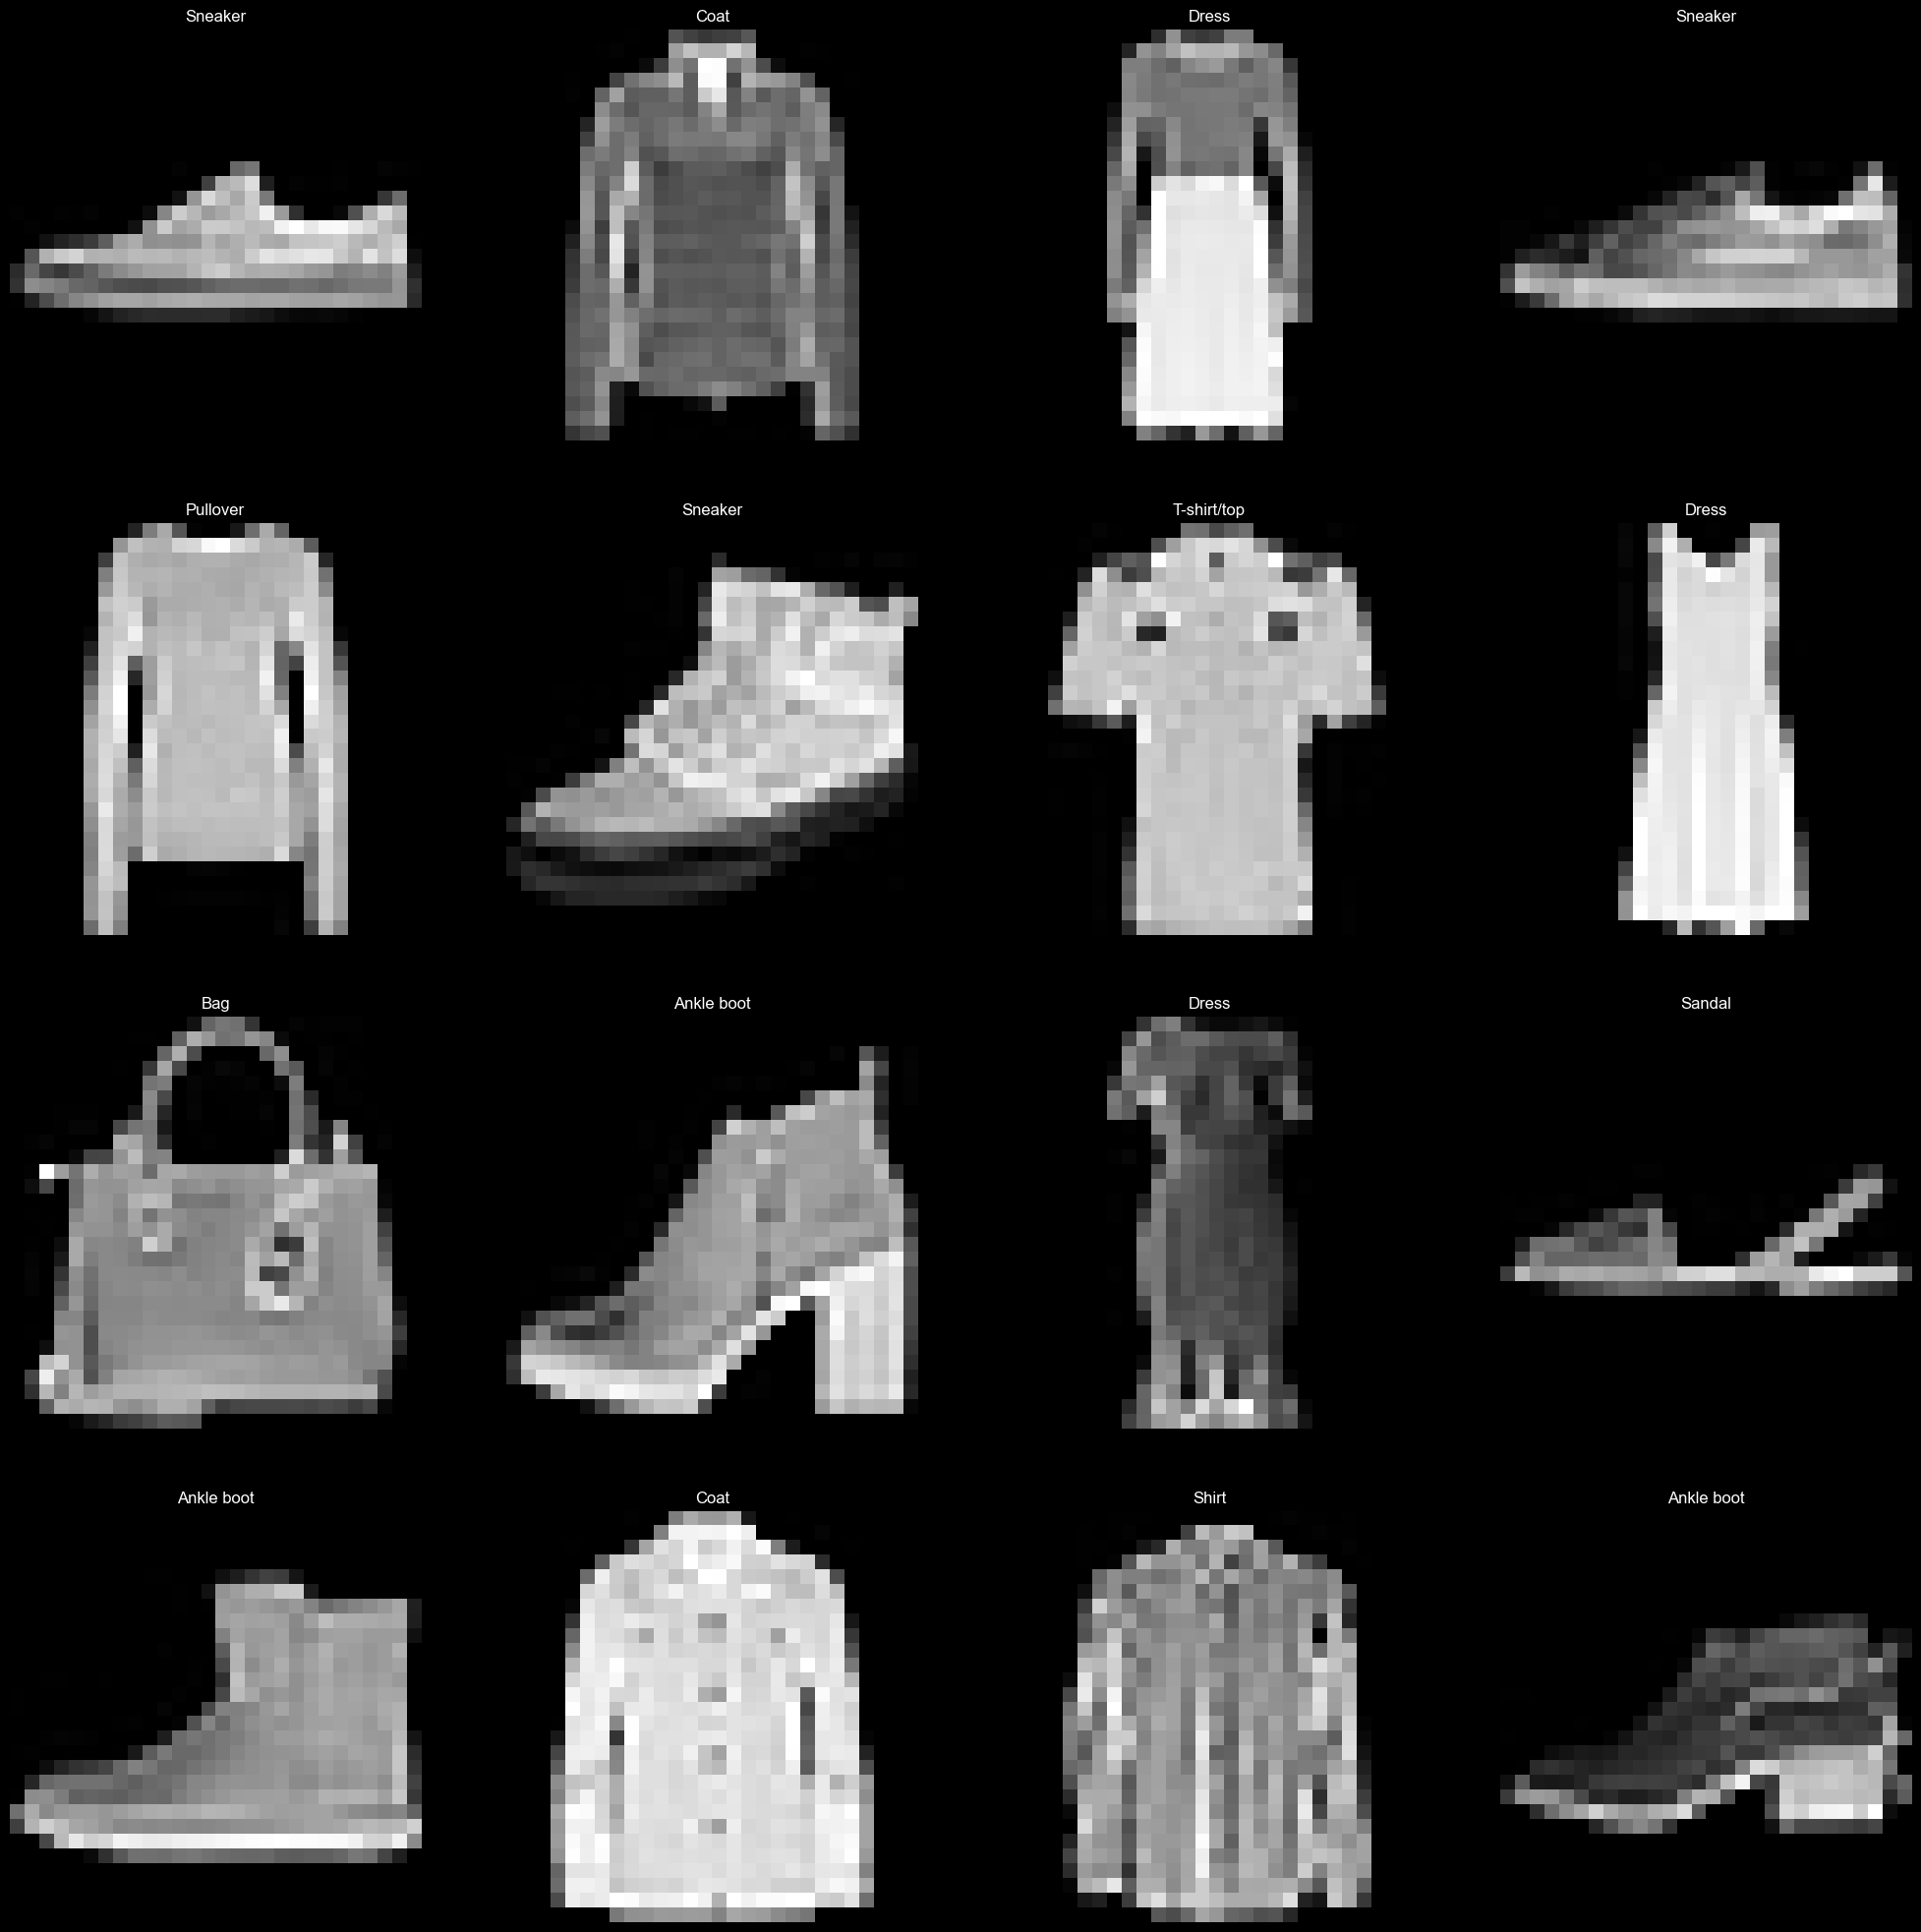

In [85]:
fig = plt.figure(figsize=(25,25))
rows, cols = 4,4
for i in range(1,rows * cols +1):
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols,i).axis('off')
  plt.imshow(img.squeeze(),cmap='gray')
  plt.title(classes[label])

lets define the netwrok:

* Convolutional layers
* Maxpooling layers
* Fully-connected (linear) layers
> adding dropout layers to avoid overfitting this data.

In [86]:
class FashionMNISTModel(nn.Module):
    def __init__(self, input_shape: int,hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
         nn.Conv2d(in_channels = input_shape ,
                   out_channels = hidden_units,
                   kernel_size=3,
                   stride=1,
                   padding=1),
         nn.ReLU(),
         nn.Conv2d(in_channels =hidden_units,
                 out_channels = hidden_units,
                 kernel_size=3,
                 stride= 1,
                 padding=1),
         nn.ReLU(),
         nn.MaxPool2d(kernel_size=2))
        self.conv_block_2 = nn.Sequential(
         nn.Conv2d(in_channels = hidden_units ,
                   out_channels = hidden_units,
                   kernel_size=3,
                   stride=1,
                   padding=1),
         nn.ReLU(),
         nn.Conv2d(in_channels =hidden_units,
                 out_channels = hidden_units,
                 kernel_size=3,
                 stride= 1,
                 padding=1),
         nn.ReLU(),
         nn.MaxPool2d(kernel_size=2))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape))
    def forward(self,x):
        x = self.conv_block_1(x)
        #print(x.shape)
        x = self.conv_block_2(x)
        #print(x.shape)
        x = self.classifier(x)
        #print(x.shape)

        return x

In [87]:
model = FashionMNISTModel(image.shape[0],10,len(classes))
model

FashionMNISTModel(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [88]:
# cross entropy loss combines softmax and nn.NLLLoss()"for being used when the output of our Net is a distribution of class scores" in one single class.
criterion = nn.CrossEntropyLoss()

# stochastic gradient descent with a small learning rate
optimizer = optim.SGD(model.parameters(), lr=0.001)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

It is important to find accuracy before and after training to compare that ur model has learned, before training  (we expect it to be around 10% which is the same accuracy as just guessing for all 10 classes).

In [89]:
# Calculate accuracy before training
correct = 0
total = 0

# Iterate through test dataset
for images, labels in test_loader:

    # forward pass to get outputs
    # the outputs are a series of class scores
    outputs = model(images)

    # get the predicted class from the maximum value in the output-list of class scores
    _, predicted = torch.max(outputs.data, 1)

    # count up total number of correct labels
    # for which the predicted and true labels are equal
    total += labels.size(0)
    correct += (predicted == labels).sum()

# calculate the accuracy
# to convert `correct` from a Tensor into a scalar, use .item()
accuracy = 100.0 * correct.item() / total

# print it out!
print('Accuracy before training: ', accuracy)

Accuracy before training:  10.0


Train the netwrok:


* Zero's the gradients to prepare for a forward pass
* Passes the input through the network (forward pass)
* Computes the loss (how far is the predicted classes are from the correct labels)
* Propagates gradients back into the network’s parameters (backward pass)
* Updates the weights (parameter update)
* Prints out the calculated loss

In [90]:

def train(n_epochs):

    loss_over_time = [] # to track the loss as the network trains

    for epoch in range(n_epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        train_acc = 0

        for batch_i, data in enumerate(train_loader):
            # get the input images and their corresponding labels
            inputs, labels = data

            # zero the parameter (weight) gradients
            optimizer.zero_grad()

            # forward pass to get outputs
            outputs = model(inputs)

            # calculate the loss
            loss = criterion(outputs, labels)
            #accuracy
            train_acc += accuracy_fn(labels,outputs.argmax(dim=1))
            # backward pass to calculate the parameter gradients
            loss.backward()

            # update the parameters
            optimizer.step()

            # print loss statistics
            # to convert loss into a scalar and add it to running_loss, we use .item()
            running_loss += loss.item()

            if batch_i % 1000 == 999:    # print every 1000 batches
                avg_loss = running_loss/1000
                avg_acc = train_acc / 1000
                # record and print the avg loss over the 1000 batches
                loss_over_time.append(avg_loss)
                train_acc /=len(train_loader)
                print('Epoch: {}, Batch: {}, Avg. Loss: {},ACC: {}%'.format(epoch + 1, batch_i+1, avg_loss,avg_acc))
                #put this ti print acc and loss each iteration
                # loss /= len(train_loader)
                #train_acc /=len(train_loader)
                #print(f"Train Loss: {loss:.5f} | Train acc: {train_acc:.2f}%")
                running_loss = 0.0
                train_acc = 0.0

    print('Finished Training')
    return loss_over_time

In [91]:
# define the number of epochs to train for
n_epochs = 2 # start small to see if your model works, initially

# call train and record the loss and acc over time
training = train(n_epochs)


Epoch: 1, Batch: 1000, Avg. Loss: 2.3031929671764373,ACC: 9.93%
Epoch: 1, Batch: 2000, Avg. Loss: 2.3013927726745607,ACC: 10.155%
Epoch: 1, Batch: 3000, Avg. Loss: 2.298867087125778,ACC: 9.935%
Epoch: 2, Batch: 1000, Avg. Loss: 2.29258763384819,ACC: 11.185%
Epoch: 2, Batch: 2000, Avg. Loss: 2.2670775680541992,ACC: 23.87%
Epoch: 2, Batch: 3000, Avg. Loss: 1.7821931993961335,ACC: 47.805%
Finished Training


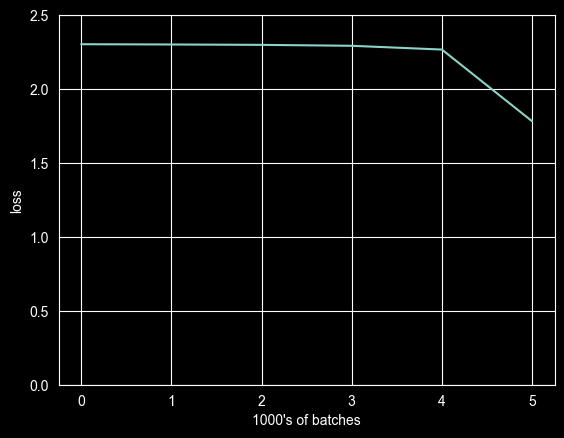

In [92]:
# visualize the loss as the network trained
plt.plot(training)
plt.xlabel('1000\'s of batches')
plt.ylabel('loss')
plt.ylim(0, 2.5) # consistent scale
plt.show()

In [93]:
# initialize tensor and lists to monitor test loss and accuracy
test_loss = torch.zeros(1)
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

# set the module to evaluation mode
model.eval()

with torch.no_grad():
    for batch_i, data in enumerate(test_loader):

        # get the input images and their corresponding labels
        inputs, labels = data

        # forward pass to get outputs
        outputs = model(inputs)

        # calculate the loss
        loss = criterion(outputs, labels)

        # update average test loss
        test_loss = test_loss + ((torch.ones(1) / (batch_i + 1)) * (loss.data - test_loss))

        # get the predicted class from the maximum value in the output-list of class scores
        _, predicted = torch.max(outputs.data, 1)

        # compare predictions to true label
        # this creates a `correct` Tensor that holds the number of correctly classified images in a batch
        correct = np.squeeze(predicted.eq(labels.data.view_as(predicted)))

        # calculate test accuracy for *each* object class
        # we get the scalar value of correct items for a class, by calling `correct[i].item()`
        for i in range(batch_size):
            label = labels.data[i]
            class_correct[label] += correct[i].item()
            class_total[label] += 1

print('Test Loss: {:.6f}\n'.format(test_loss.numpy()[0]))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))


print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 1.002518

Test Accuracy of T-shirt/top: 71% (717/1000)
Test Accuracy of Trouser: 82% (829/1000)
Test Accuracy of Pullover: 73% (739/1000)
Test Accuracy of Dress: 74% (746/1000)
Test Accuracy of  Coat: 49% (495/1000)
Test Accuracy of Sandal: 16% (165/1000)
Test Accuracy of Shirt:  3% (34/1000)
Test Accuracy of Sneaker: 91% (916/1000)
Test Accuracy of   Bag: 75% (752/1000)
Test Accuracy of Ankle boot: 90% (907/1000)

Test Accuracy (Overall): 63% (6300/10000)


In [94]:
def train_step(model,
               data_loader,
               loss_fn,
               optimizer,
               accuracy_fn,
               device):
  train_loss, train_acc = 0, 0
  model.to(device)
  for batch, (X,y) in enumerate(data_loader):
    X, y= X.to(device),y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred,y)
    train_loss += loss
    train_acc += accuracy_fn(y,y_pred.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /=len(data_loader)
  print(f"Train Loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")

In [95]:
def test_step(model,
              data_loader,
              loss_fn,
              accuracy_fn,
              device):
  test_loss, test_acc= 0,0
  model.to(device)
  model.eval()
  with torch.inference_mode():

    for X,y in data_loader:
      X, y= X.to(device),y.to(device)

      test_pred = model(X)

      test_loss +=loss_fn(test_pred,y)
      test_acc += accuracy_fn(y, test_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

In [96]:
from tqdm.auto import tqdm

torch.manual_seed(42)
# Train and test model
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_loader,
        model=model,
        loss_fn=criterion,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_loader,
        model=model,
        loss_fn=criterion,
        accuracy_fn=accuracy_fn,
        device=device
    )

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train Loss: 0.78787 | Train acc: 71.01%


 33%|███▎      | 1/3 [00:21<00:43, 21.70s/it]

Test loss: 0.69815, Test acc: 74.81%

Epoch: 1
---------
Train Loss: 0.68249 | Train acc: 75.20%


 67%|██████▋   | 2/3 [00:43<00:22, 22.00s/it]

Test loss: 0.69875, Test acc: 75.48%

Epoch: 2
---------
Train Loss: 0.64141 | Train acc: 76.73%


100%|██████████| 3/3 [01:04<00:00, 21.47s/it]

Test loss: 0.64164, Test acc: 76.42%



1. Graine aléatoire
torch.manual_seed(42)
Fixe la seed pour la reproductibilité :
💡 Avec la même seed, les résultats seront identiques à chaque exécution — utile pour déboguer et comparer.


Boucle principale avec barre de progression
epochs = 3
for epoch in tqdm(range(epochs)):
tqdm enveloppe range(epochs) et affiche :
100%|██████████| 3/3 [01:24<00:00, 28.3s/it]


In [97]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({classes[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


In [98]:
# Redefine make_predictions to ensure tensors are on the correct device
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    # Ensure the model is on the specified device. It might already be from training.
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0) # Add an extra dimension
            sample = sample.to(device) # Move sample to the specified device

            pred_logit = model(sample)

            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            pred_probs.append(pred_prob.cpu()) # Move result back to CPU if needed

    return torch.stack(pred_probs)

pred_probs = make_predictions(model=model,
                             data=test_samples,
                             device=device) # Explicitly pass device for clarity, though it defaults correctly here.
pred_probs[:2]
# Turn the prediction probabilities into prediction labels by taking the argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [99]:
# Are our predictions in the same form as our test labels?
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

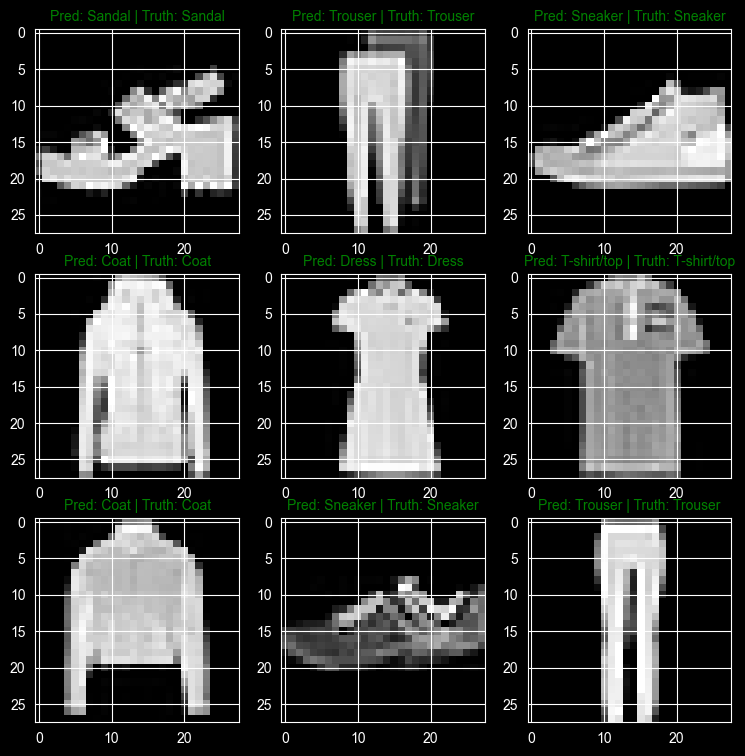

In [100]:
#visualize test
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)

  plt.imshow(sample.squeeze(), cmap="gray")

  pred_label = classes[pred_classes[i]]

  truth_label = classes[test_labels[i]]

  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong

In [101]:
y_preds = []
model.eval()
with torch.inference_mode():
  for X, y in tqdm(test_loader, desc="Making predictions"):
    X, y = X.to(device), y.to(device)
    y_logit = model(X)
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    y_preds.append(y_pred.cpu())
y_pred_tensor = torch.cat(y_preds)

Making predictions: 100%|██████████| 500/500 [00:00<00:00, 638.20it/s]


In [102]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report

In [103]:
report = classification_report(test_data.targets, y_pred_tensor, target_names=classes)
print(report)

              precision    recall  f1-score   support

 T-shirt/top       0.09      0.08      0.08      1000
     Trouser       0.10      0.09      0.10      1000
    Pullover       0.10      0.06      0.07      1000
       Dress       0.09      0.10      0.10      1000
        Coat       0.11      0.11      0.11      1000
      Sandal       0.10      0.08      0.09      1000
       Shirt       0.10      0.13      0.11      1000
     Sneaker       0.09      0.11      0.10      1000
         Bag       0.10      0.11      0.10      1000
  Ankle boot       0.11      0.10      0.11      1000

    accuracy                           0.10     10000
   macro avg       0.10      0.10      0.10     10000
weighted avg       0.10      0.10      0.10     10000



In [104]:
# from tensorflow.keras.utils import to_categorical
# # Ensure tensors are on CPU before converting to categorical
# y_true_one_hot = to_categorical(test_data.targets.cpu())
# y_pred_one_hot = to_categorical(y_pred_tensor.cpu())

# Convert integer labels to one-hot encoded tensors using pure PyTorch
# We pass num_classes=10 to ensure the array is exactly 10 slots long
y_true_one_hot = F.one_hot(test_data.targets.cpu(), num_classes=len(classes))
y_pred_one_hot = F.one_hot(y_pred_tensor.cpu(), num_classes=len(classes))

# Let's print one out to see what it looks like!
print("Original integer label:", test_data.targets[0].item())
print("One-Hot Encoded label:", y_true_one_hot[0])

Original integer label: 9
One-Hot Encoded label: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])


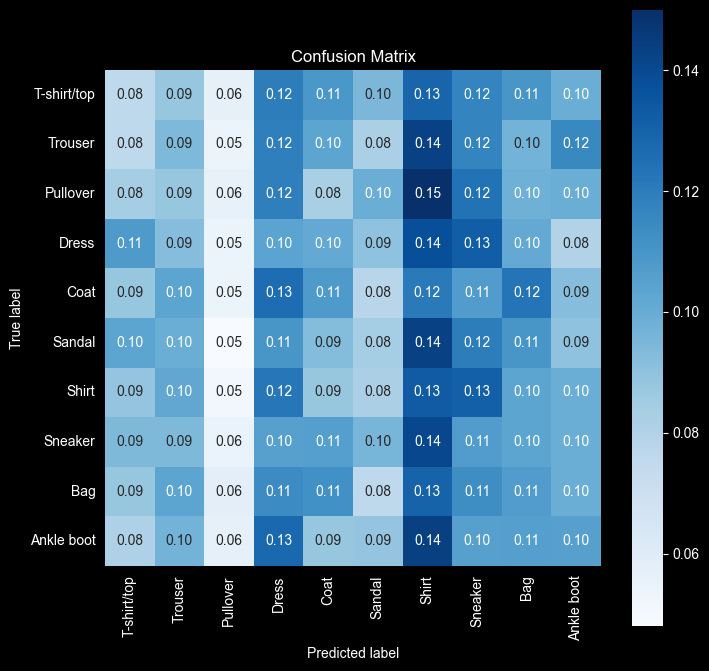

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

y_true_labels = test_data.targets.cpu().numpy()
y_pred_labels = y_pred_tensor.cpu().numpy()

# Generating confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plotting confusion matrix
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', square=True,
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()


To save
* Model_dir = 'saved_models/'
* Model_name = 'fashion_net_ex.pt'
* After training, save your model parameters in the dir 'saved_models'
* Torch.save(net.state_dict(), model_dir+model_name)

Building another CNN model:

#Two Sequential layers each consists of following layers-

1. Convolution layer that has kernel size of 3 * 3, padding = 1 (zero_padding) in 1st layer and padding = 0 in second one. Stride of 1 in both layer.
1. Batch Normalization layer.
1. Acitvation function: ReLU.
1. Max Pooling layer with kernel size of 2 * 2 and stride 2.
1. Flatten out the output for dense layer(a.k.a. fully connected layer).
1. 3 Fully connected layer with different in/out features.
1. 1 Dropout layer that has class probability p = 0.25.
1. All the functionaltiy is given in forward method that defines the forward pass of CNN.
1. Our input image is changing in a following way:
1. First Convulation layer : input: 28 * 28 * 3, output: 28 * 28 * 32
1. First Max Pooling layer : input: 28 * 28 * 32, output: 14 * 14 * 32
1. Second Conv layer : input : 14 * 14 * 32, output: 12 * 12 * 64
1. Second Max Pooling layer : 12 * 12 * 64, output: 6 * 6 * 64
1. Final fully connected layer has 10 output features for 10 types of clothes.

In [106]:
class FashionCNN(nn.Module):

    def __init__(self):
        super(FashionCNN, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)

        return out

In [107]:
# 31
model = FashionCNN()

error = nn.CrossEntropyLoss()

learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


Training and testing the network

In [108]:
num_epochs = 5
count = 0
# Lists for visualization of loss and accuracy
loss_list = []
iteration_list = []
accuracy_list = []

# Lists for knowing classwise accuracy
predictions_list = []
labels_list = []

model.to(device) # Move the model to the specified device (GPU if available)

for epoch in range(num_epochs):
    for images, labels in train_loader:
        # Transfering images and labels to GPU if available
        images, labels = images.to(device), labels.to(device)
     # Reshaping images to fit into the model
        train = images


        # Forward pass
        outputs = model(train)
        loss = error(outputs, labels)

        # Initializing a gradient as 0 so there is no mixing of gradient among the batches
        optimizer.zero_grad()

        #Propagating the error backward
        loss.backward()

        # Optimizing the parameters
        optimizer.step()

        count += 1

    # Testing the model

        if not (count % 50):    # It's same as "if count % 50 == 0"
            total = 0
            correct = 0

            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)

                test = images

                outputs = model(test)

                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()

                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))


/Users/mac/Documents/CI-GI/S4/deeplerning/FashionMNIST-CNN-Densenet/.venv/lib/python3.13/site-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration: 500, Loss: 0.13746407628059387, Accuracy: 81.66999816894531%
Iteration: 1000, Loss: 0.5389453172683716, Accuracy: 84.63999938964844%
Iteration: 1500, Loss: 0.21927516162395477, Accuracy: 86.16999816894531%
Iteration: 2000, Loss: 0.08770330995321274, Accuracy: 85.86000061035156%
Iteration: 2500, Loss: 0.7278020977973938, Accuracy: 86.41000366210938%
Iteration: 3000, Loss: 0.19608929753303528, Accuracy: 87.26000213623047%
Iteration: 3500, Loss: 0.20405499637126923, Accuracy: 87.7699966430664%
Iteration: 4000, Loss: 0.666196882724762, Accuracy: 89.43000030517578%
Iteration: 4500, Loss: 0.852916419506073, Accuracy: 88.30999755859375%
Iteration: 5000, Loss: 0.34347784519195557, Accuracy: 89.51000213623047%
Iteration: 5500, Loss: 0.1661394238471985, Accuracy: 88.7699966430664%
Iteration: 6000, Loss: 0.3043947219848633, Accuracy: 89.55000305175781%
Iteration: 6500, Loss: 0.579720675945282, Accuracy: 89.41999816894531%
Iteration: 7000, Loss: 0.5380948185920715, Accuracy: 89.52999877

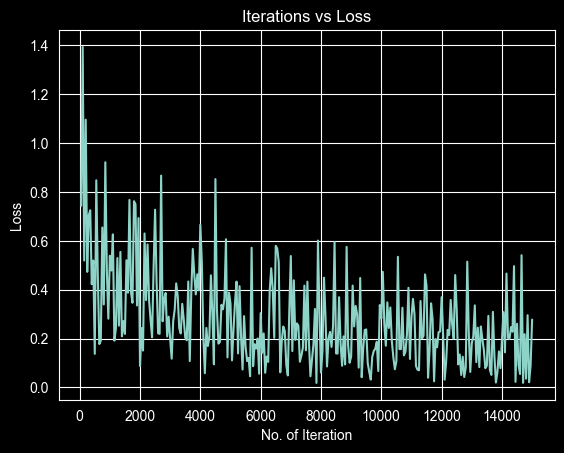

In [109]:
plt.plot(iteration_list, loss_list)
plt.xlabel("No. of Iteration")
plt.ylabel("Loss")
plt.title("Iterations vs Loss")
plt.show()

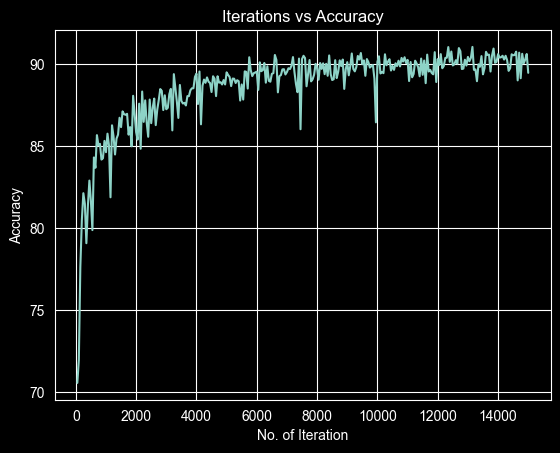

In [110]:
plt.plot(iteration_list, accuracy_list)
plt.xlabel("No. of Iteration")
plt.ylabel("Accuracy")
plt.title("Iterations vs Accuracy")
plt.show()

# Densenet

In [111]:
# 35
import torch
from torchvision import transforms
from torchvision.datasets import MNIST

# Define custom transformation
class CustomTransform:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, image):
        # Check if the image is grayscale (single channel)
        if image.shape[0] == 1:
            # Convert the single-channel image to a 3-channel image
            image = torch.cat([image, image, image], dim=0)

        # Apply normalization
        normalize = transforms.Normalize(mean=self.mean, std=self.std)
        image = normalize(image)

        return image

# Define mean and std values for normalization
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Create custom transformation
custom_transform = CustomTransform(mean=mean, std=std)

# Define data transformations for pretrained models
data_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    custom_transform
])

# Load the MNIST dataset
dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)

# Apply transformations to the dataset
dataset.transform = data_transform

# Example of accessing a transformed image from the dataset
image, label = dataset[0]
print("Transformed Image Shape:", image.shape)


Transformed Image Shape: torch.Size([3, 224, 224])


In [112]:
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)
#trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(dataset, batch_size=1, shuffle=True)

In [113]:
image, label = dataset[0]
image.shape


torch.Size([3, 224, 224])

In [114]:
from torchvision import models

# Load pretrained models
alexnet = models.alexnet(pretrained=True)
resnet = models.resnet18(pretrained=True)
vgg16 = models.vgg16(pretrained=True)


/Users/mac/Documents/CI-GI/S4/deeplerning/FashionMNIST-CNN-Densenet/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/mac/Documents/CI-GI/S4/deeplerning/FashionMNIST-CNN-Densenet/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /Users/mac/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100.0%
/Users/mac/Documents/CI-GI/S4/deeplerning/FashionMNIST-CNN-Densenet/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/mac/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%
/Users/mac/Documents/CI-GI/S4/deeplerning/FashionMNIST-CNN-Densenet/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/mac/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100.0%


In [115]:

# Modify models for MNIST
num_classes = 10

alexnet.classifier[6] = nn.Linear(4096, num_classes)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
vgg16.classifier[6] = nn.Linear(4096, num_classes)

# Move models to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
alexnet.to(device)
resnet.to(device)
vgg16.to(device)

# Example forward pass
for images, labels in train_loader:
    images = images.to(device)

    # AlexNet
    outputs_alexnet = alexnet(images)

    # ResNet
    outputs_resnet = resnet(images)

    # VGG16
    outputs_vgg16 = vgg16(images)

    break  # Only do one iteration for demonstration

print("AlexNet Output Shape:", outputs_alexnet.shape)
print("ResNet Output Shape:", outputs_resnet.shape)
print("VGG16 Output Shape:", outputs_vgg16.shape)

AlexNet Output Shape: torch.Size([32, 10])
ResNet Output Shape: torch.Size([32, 10])
VGG16 Output Shape: torch.Size([32, 10])


In [116]:
from torchvision import models
alexnet = models.alexnet(pretrained=True)
alexnet


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [117]:
# Freeze model parameters
for param in alexnet.parameters():
    param.requires_grad = False

In [118]:
# Change the final layer of AlexNet Model for Transfer Learning
alexnet.classifier[6] = nn.Linear(4096, 10)
alexnet.classifier.add_module("10", nn.LogSoftmax(dim = 1))
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [119]:
# Define Optimizer and Loss Function
loss_func = nn.NLLLoss()
optimizer = optim.Adam(alexnet.parameters())
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [120]:

def train(n_epochs):

    loss_over_time = [] # to track the loss as the network trains

    for epoch in range(n_epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        train_acc = 0

        for batch_i, data in enumerate(train_loader):
            # get the input images and their corresponding labels
            inputs, labels = data

            # zero the parameter (weight) gradients
            optimizer.zero_grad()

            # forward pass to get outputs
            outputs = alexnet(inputs)

            # calculate the loss
            loss = criterion(outputs, labels)
            #accuracy
            train_acc += accuracy_fn(labels,outputs.argmax(dim=1))
            # backward pass to calculate the parameter gradients
            loss.backward()

            # update the parameters
            optimizer.step()

            # print loss statistics
            # to convert loss into a scalar and add it to running_loss, we use .item()
            running_loss += loss.item()

            if batch_i % 1000 == 999:    # print every 1000 batches
                avg_loss = running_loss/1000
                # record and print the avg loss over the 1000 batches
                loss_over_time.append(avg_loss)
                train_acc /=len(train_loader)
                print('Epoch: {}, Batch: {}, Avg. Loss: {},ACC: {}%'.format(epoch + 1, batch_i+1, avg_loss,train_acc))
                #put this ti print acc and loss each iteration
                # loss /= len(train_loader)
                #train_acc /=len(train_loader)
                #print(f"Train Loss: {loss:.5f} | Train acc: {train_acc:.2f}%")
                running_loss = 0.0

    print('Finished Training')
    return loss_over_time

In [121]:
# define the number of epochs to train for
n_epochs = 2 # start small to see if your model works, initially

# call train and record the loss and acc over time
training = train(n_epochs)


Epoch: 1, Batch: 1000, Avg. Loss: 0.5936454723551869,ACC: 42.25666666666667%
Epoch: 2, Batch: 1000, Avg. Loss: 0.5086655198931694,ACC: 43.931666666666665%
Finished Training


In [122]:
from torchvision import models
import torch
dir(models)

['AlexNet',
 'AlexNet_Weights',
 'ConvNeXt',
 'ConvNeXt_Base_Weights',
 'ConvNeXt_Large_Weights',
 'ConvNeXt_Small_Weights',
 'ConvNeXt_Tiny_Weights',
 'DenseNet',
 'DenseNet121_Weights',
 'DenseNet161_Weights',
 'DenseNet169_Weights',
 'DenseNet201_Weights',
 'EfficientNet',
 'EfficientNet_B0_Weights',
 'EfficientNet_B1_Weights',
 'EfficientNet_B2_Weights',
 'EfficientNet_B3_Weights',
 'EfficientNet_B4_Weights',
 'EfficientNet_B5_Weights',
 'EfficientNet_B6_Weights',
 'EfficientNet_B7_Weights',
 'EfficientNet_V2_L_Weights',
 'EfficientNet_V2_M_Weights',
 'EfficientNet_V2_S_Weights',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'GoogLeNet_Weights',
 'Inception3',
 'InceptionOutputs',
 'Inception_V3_Weights',
 'MNASNet',
 'MNASNet0_5_Weights',
 'MNASNet0_75_Weights',
 'MNASNet1_0_Weights',
 'MNASNet1_3_Weights',
 'MaxVit',
 'MaxVit_T_Weights',
 'MobileNetV2',
 'MobileNetV3',
 'MobileNet_V2_Weights',
 'MobileNet_V3_Large_Weights',
 'MobileNet_V3_Small_Weights',
 'RegNet',
 'RegNet_X_16GF_Weights'